# Notebook 06 — Model Training: XGBoost & LightGBM with Optuna

**Project**: ML-Based QSAR Modeling for Anti-Leishmanial Sulfonamide Derivatives
**Input**: `data/processed/X_train_selected.csv`, `y_train.csv`
**Output**:
- `models/xgb_classifier.joblib` — Optimised XGBoost classifier
- `models/lgbm_classifier.joblib` — Optimised LightGBM classifier
- `results/model_metrics/cv_scores_nb06.csv` — 5-fold CV metrics

**Strategy** (class imbalance handled natively — no SMOTE needed):
- XGB: `scale_pos_weight`, 5 000-sample subsample for Optuna, 30 trials
- LGBM: `is_unbalance=True`, full dataset for Optuna, 30 trials (LGBM is fast)
- Final models fitted on full training set

**QC-5 (continued)**: XGB/LGBM CV balanced accuracy expected > 0.75.

---

In [1]:
# ============================================================
# CELL 1: Imports and Configuration
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings, sys, joblib
from datetime import datetime

warnings.filterwarnings('ignore')

import xgboost as xgb
import lightgbm as lgb

from sklearn.model_selection import (StratifiedKFold, StratifiedShuffleSplit,
                                     cross_validate)
from sklearn.metrics import make_scorer, matthews_corrcoef
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

SEED = 42
np.random.seed(SEED)

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT))

(PROJECT_ROOT / 'models').mkdir(parents=True, exist_ok=True)
(PROJECT_ROOT / 'results' / 'model_metrics').mkdir(parents=True, exist_ok=True)
(PROJECT_ROOT / 'figures').mkdir(parents=True, exist_ok=True)

print(f"Project root : {PROJECT_ROOT}")
print(f"XGBoost      : {xgb.__version__}")
print(f"LightGBM     : {lgb.__version__}")
print(f"Timestamp    : {datetime.now().strftime('%Y-%m-%d %H:%M')}")


Project root : E:\PhD_Projecttttttttttttt\PhD_QSAR_Leishmania
XGBoost      : 3.2.0
LightGBM     : 4.6.0
Timestamp    : 2026-05-10 10:24


In [2]:
# ============================================================
# CELL 2: Load Feature-Selected Training Data
# ============================================================

DATA_DIR = PROJECT_ROOT / 'data' / 'processed'

X_train = pd.read_csv(DATA_DIR / 'X_train_selected.csv', index_col=0)
y_df    = pd.read_csv(DATA_DIR / 'y_train.csv', index_col=0)
y_train = (y_df['activity_class'] == 'Active').astype(int)

# Align on shared index
common_idx = X_train.index.intersection(y_train.index)
X_train = X_train.loc[common_idx].values   # numpy arrays — faster for tree models
y_train = y_train.loc[common_idx].values

n_active   = int(y_train.sum())
n_inactive = len(y_train) - n_active
scale_pos_weight = n_inactive / n_active   # for XGBoost class weighting

print(f"X_train shape      : {X_train.shape}")
print(f"y_train            : {len(y_train)} samples")
print(f"  Active (1)       : {n_active}  ({n_active/len(y_train)*100:.1f}%)")
print(f"  Inactive (0)     : {n_inactive}  ({n_inactive/len(y_train)*100:.1f}%)")
print(f"scale_pos_weight   : {scale_pos_weight:.3f}  (used by XGBoost)")


X_train shape      : (9563, 943)
y_train            : 9563 samples
  Active (1)       : 5290  (55.3%)
  Inactive (0)     : 4273  (44.7%)
scale_pos_weight   : 0.808  (used by XGBoost)


In [3]:
# ============================================================
# CELL 3: CV Strategy, Scoring, and XGB Search Subsample
# ============================================================

cv3 = StratifiedKFold(n_splits=3, shuffle=True, random_state=SEED)
cv5 = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

scoring = {
    'balanced_accuracy': 'balanced_accuracy',
    'f1'               : 'f1',
    'mcc'              : make_scorer(matthews_corrcoef),
    'roc_auc'          : 'roc_auc',
}

# 5 000-sample subsample for XGB Optuna (XGB is slower than LGBM)
sss = StratifiedShuffleSplit(n_splits=1, train_size=5000, random_state=SEED)
xgb_sub_idx, _ = next(sss.split(X_train, y_train))
X_xgb_sub = X_train[xgb_sub_idx]
y_xgb_sub = y_train[xgb_sub_idx]

n_sub_active   = int(y_xgb_sub.sum())
spw_sub        = (len(y_xgb_sub) - n_sub_active) / n_sub_active

print(f"XGB search subsample : {X_xgb_sub.shape}  (active={n_sub_active})")
print(f"  scale_pos_weight   : {spw_sub:.3f}")
print(f"LGBM search          : full dataset {X_train.shape}  (very fast)")


XGB search subsample : (5000, 943)  (active=2766)
  scale_pos_weight   : 0.808
LGBM search          : full dataset (9563, 943)  (very fast)


In [4]:
# ============================================================
# CELL 4: XGBoost — Optuna Hyperparameter Optimisation
#         (5 000-sample subsample, 3-fold CV, 30 trials)
# ============================================================

def objective_xgb(trial):
    params = {
        'n_estimators'     : trial.suggest_int('n_estimators', 100, 500, step=100),
        'max_depth'        : trial.suggest_int('max_depth', 3, 12),
        'learning_rate'    : trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'min_child_weight' : trial.suggest_int('min_child_weight', 1, 10),
        'subsample'        : trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree' : trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'scale_pos_weight' : spw_sub,
    }
    model = xgb.XGBClassifier(
        **params, random_state=SEED, n_jobs=-1,
        eval_metric='logloss', verbosity=0, device='cpu'
    )
    res = cross_validate(model, X_xgb_sub, y_xgb_sub, cv=cv3,
                         scoring='balanced_accuracy', n_jobs=1)
    return res['test_score'].mean()

print("Starting XGBoost optimisation (30 trials on 5 000-sample subset) ...")
study_xgb = optuna.create_study(
    direction='maximize',
    sampler=optuna.samplers.TPESampler(seed=SEED)
)
study_xgb.optimize(objective_xgb, n_trials=30, timeout=1800)

print(f"XGBoost optimisation done  ({len(study_xgb.trials)} trials completed)")
print(f"  Best BA (3-fold, subsample): {study_xgb.best_value:.4f}")
print(f"  Best params: {study_xgb.best_params}")


Starting XGBoost optimisation (30 trials on 5 000-sample subset) ...


XGBoost optimisation done  (22 trials completed)
  Best BA (3-fold, subsample): 0.7364
  Best params: {'n_estimators': 400, 'max_depth': 9, 'learning_rate': 0.01784941781784679, 'min_child_weight': 3, 'subsample': 0.8746286605774732, 'colsample_bytree': 0.6273460108477902}


In [5]:
# ============================================================
# CELL 5: Train Final XGBoost — Full 5-Fold CV + Full Fit
# ============================================================

best_xgb_params = {**study_xgb.best_params, 'scale_pos_weight': scale_pos_weight}

best_xgb_model = xgb.XGBClassifier(
    **best_xgb_params,
    random_state=SEED, n_jobs=-1,
    eval_metric='logloss', verbosity=0, device='cpu'
)

print("5-fold CV on full training set (XGBoost) ...")
xgb_cv = cross_validate(best_xgb_model, X_train, y_train,
                        cv=cv5, scoring=scoring, n_jobs=1)

xgb_mean = {k.replace('test_', ''): v.mean()
            for k, v in xgb_cv.items() if k.startswith('test_')}
xgb_std  = {k.replace('test_', ''): v.std()
            for k, v in xgb_cv.items() if k.startswith('test_')}

print("XGBoost 5-Fold CV Results (full data):")
for m, v in xgb_mean.items():
    print(f"  {m:<22}: {v:.4f} +/- {xgb_std[m]:.4f}")

print("\nFitting final XGBoost on full training set ...")
best_xgb_model.fit(X_train, y_train)
joblib.dump(best_xgb_model, PROJECT_ROOT / 'models' / 'xgb_classifier.joblib')
print("Saved -> models/xgb_classifier.joblib")


5-fold CV on full training set (XGBoost) ...


XGBoost 5-Fold CV Results (full data):
  balanced_accuracy     : 0.7642 +/- 0.0083
  f1                    : 0.7819 +/- 0.0078
  mcc                   : 0.5263 +/- 0.0166
  roc_auc               : 0.8444 +/- 0.0089

Fitting final XGBoost on full training set ...


Saved -> models/xgb_classifier.joblib


In [6]:
# ============================================================
# CELL 6: LightGBM — Optuna Hyperparameter Optimisation
#         (full dataset, 3-fold CV, 30 trials — LGBM is fast)
# ============================================================

def objective_lgbm(trial):
    params = {
        'n_estimators'     : trial.suggest_int('n_estimators', 100, 1000, step=100),
        'num_leaves'       : trial.suggest_int('num_leaves', 20, 150),
        'learning_rate'    : trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'min_child_samples': trial.suggest_int('min_child_samples', 5, 50),
        'feature_fraction' : trial.suggest_float('feature_fraction', 0.5, 1.0),
        'bagging_fraction' : trial.suggest_float('bagging_fraction', 0.5, 1.0),
        'bagging_freq'     : trial.suggest_int('bagging_freq', 1, 7),
        'is_unbalance'     : True,
    }
    model = lgb.LGBMClassifier(
        **params, random_state=SEED, n_jobs=-1, verbose=-1
    )
    res = cross_validate(model, X_train, y_train, cv=cv3,
                         scoring='balanced_accuracy', n_jobs=1)
    return res['test_score'].mean()

print("Starting LightGBM optimisation (30 trials on full dataset) ...")
study_lgbm = optuna.create_study(
    direction='maximize',
    sampler=optuna.samplers.TPESampler(seed=SEED)
)
study_lgbm.optimize(objective_lgbm, n_trials=30, timeout=1800)

print(f"LightGBM optimisation done  ({len(study_lgbm.trials)} trials completed)")
print(f"  Best BA (3-fold, full data): {study_lgbm.best_value:.4f}")
print(f"  Best params: {study_lgbm.best_params}")


Starting LightGBM optimisation (30 trials on full dataset) ...


LightGBM optimisation done  (16 trials completed)
  Best BA (3-fold, full data): 0.7567
  Best params: {'n_estimators': 800, 'num_leaves': 77, 'learning_rate': 0.016689987314798864, 'min_child_samples': 23, 'feature_fraction': 0.6214627172034821, 'bagging_fraction': 0.8512473680507769, 'bagging_freq': 3}


In [7]:
# ============================================================
# CELL 7: Train Final LightGBM — Full 5-Fold CV + Full Fit
# ============================================================

best_lgbm_model = lgb.LGBMClassifier(
    **study_lgbm.best_params,
    random_state=SEED, n_jobs=-1, verbose=-1
)

print("5-fold CV on full training set (LightGBM) ...")
lgbm_cv = cross_validate(best_lgbm_model, X_train, y_train,
                         cv=cv5, scoring=scoring, n_jobs=1)

lgbm_mean = {k.replace('test_', ''): v.mean()
             for k, v in lgbm_cv.items() if k.startswith('test_')}
lgbm_std  = {k.replace('test_', ''): v.std()
             for k, v in lgbm_cv.items() if k.startswith('test_')}

print("LightGBM 5-Fold CV Results (full data):")
for m, v in lgbm_mean.items():
    print(f"  {m:<22}: {v:.4f} +/- {lgbm_std[m]:.4f}")

print("\nFitting final LightGBM on full training set ...")
best_lgbm_model.fit(X_train, y_train)
joblib.dump(best_lgbm_model, PROJECT_ROOT / 'models' / 'lgbm_classifier.joblib')
print("Saved -> models/lgbm_classifier.joblib")


5-fold CV on full training set (LightGBM) ...


LightGBM 5-Fold CV Results (full data):
  balanced_accuracy     : 0.7596 +/- 0.0075
  f1                    : 0.7877 +/- 0.0079
  mcc                   : 0.5203 +/- 0.0156
  roc_auc               : 0.8463 +/- 0.0075

Fitting final LightGBM on full training set ...


Saved -> models/lgbm_classifier.joblib


In [8]:
# ============================================================
# CELL 8: Save Metrics and Cross-Notebook Summary (RF+SVM+XGB+LGBM)
# ============================================================

metrics_dir = PROJECT_ROOT / 'results' / 'model_metrics'

cv_nb06 = pd.DataFrame([
    {'model': 'XGBoost',
     'n_optuna_trials': len(study_xgb.trials),
     'optuna_best_BA' : round(study_xgb.best_value, 4),
     **{f'cv_{k}': round(v, 4) for k, v in xgb_mean.items()},
     **{f'cv_{k}_std': round(v, 4) for k, v in xgb_std.items()}},
    {'model': 'LightGBM',
     'n_optuna_trials': len(study_lgbm.trials),
     'optuna_best_BA' : round(study_lgbm.best_value, 4),
     **{f'cv_{k}': round(v, 4) for k, v in lgbm_mean.items()},
     **{f'cv_{k}_std': round(v, 4) for k, v in lgbm_std.items()}},
])
cv_nb06.to_csv(metrics_dir / 'cv_scores_nb06.csv', index=False)
print("Saved -> results/model_metrics/cv_scores_nb06.csv")

# Best hyperparameters
hp_df = pd.DataFrame([
    {'model': 'XGBoost',  **study_xgb.best_params},
    {'model': 'LightGBM', **study_lgbm.best_params},
])
hp_df.to_csv(metrics_dir / 'best_hyperparams_nb06.csv', index=False)
print("Saved -> results/model_metrics/best_hyperparams_nb06.csv")

# Combined 4-model summary (load RF/SVM from nb05)
nb05_metrics = pd.read_csv(metrics_dir / 'cv_scores_nb05.csv')
all_metrics = pd.concat([nb05_metrics, cv_nb06], ignore_index=True)
all_metrics.to_csv(metrics_dir / 'cv_scores_all_models.csv', index=False)
print("Saved -> results/model_metrics/cv_scores_all_models.csv")

print()
print("All 4 models — CV Performance Summary:")
cols = ['model', 'cv_balanced_accuracy', 'cv_f1', 'cv_mcc', 'cv_roc_auc']
print(all_metrics[cols].to_string(index=False))


Saved -> results/model_metrics/cv_scores_nb06.csv
Saved -> results/model_metrics/best_hyperparams_nb06.csv


Saved -> results/model_metrics/cv_scores_all_models.csv

All 4 models — CV Performance Summary:


   model  cv_balanced_accuracy  cv_f1  cv_mcc  cv_roc_auc
      RF                0.7582 0.7763  0.5143      0.8435
     SVM                0.7342 0.7699  0.4715      0.8161
 XGBoost                0.7642 0.7819  0.5263      0.8444
LightGBM                0.7596 0.7877  0.5203      0.8463


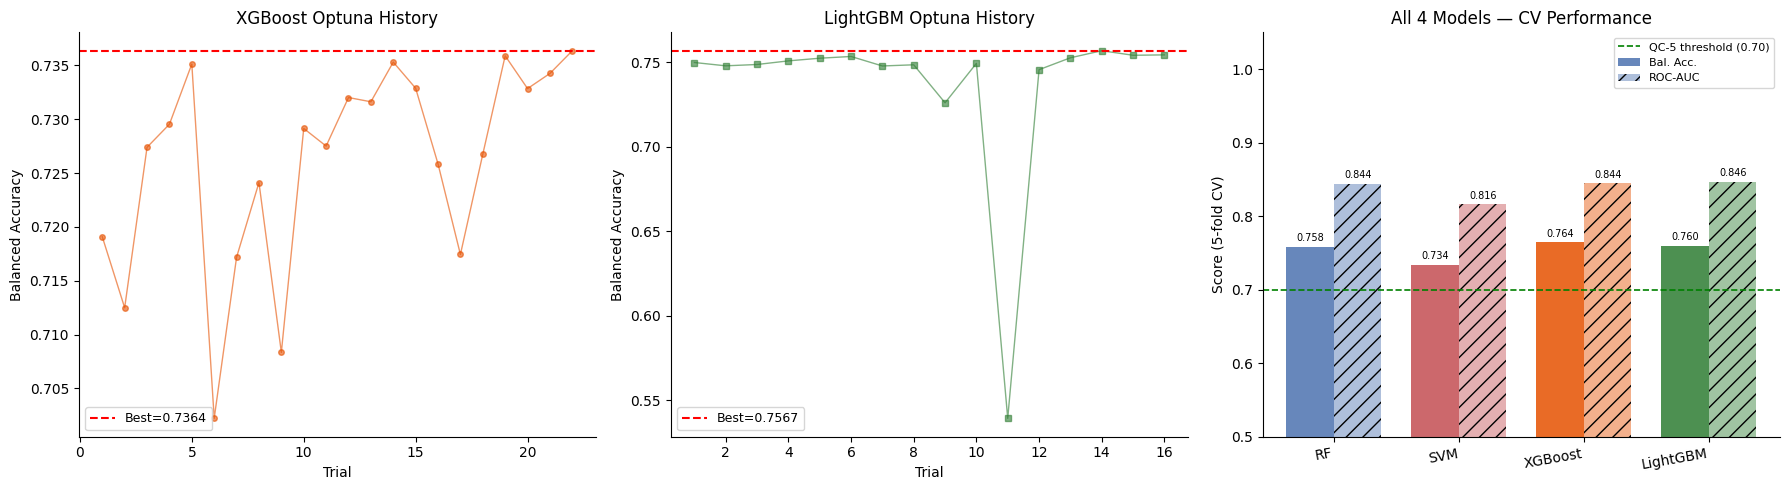

Figure saved -> figures/nb06_training_summary.png


In [9]:
# ============================================================
# CELL 9: Visualisation — Optuna History & 4-Model Comparison
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Panel 1: XGB Optuna history
ax = axes[0]
xgb_vals = [t.value for t in study_xgb.trials if t.value is not None]
ax.plot(range(1, len(xgb_vals)+1), xgb_vals, 'o-', color='#E65100',
        alpha=0.6, markersize=4, linewidth=1)
ax.axhline(study_xgb.best_value, color='red', linestyle='--',
           linewidth=1.5, label=f'Best={study_xgb.best_value:.4f}')
ax.set_xlabel('Trial'); ax.set_ylabel('Balanced Accuracy')
ax.set_title('XGBoost Optuna History'); ax.legend(fontsize=9)
sns.despine(ax=ax)

# Panel 2: LGBM Optuna history
ax = axes[1]
lgbm_vals = [t.value for t in study_lgbm.trials if t.value is not None]
ax.plot(range(1, len(lgbm_vals)+1), lgbm_vals, 's-', color='#2E7D32',
        alpha=0.6, markersize=4, linewidth=1)
ax.axhline(study_lgbm.best_value, color='red', linestyle='--',
           linewidth=1.5, label=f'Best={study_lgbm.best_value:.4f}')
ax.set_xlabel('Trial'); ax.set_ylabel('Balanced Accuracy')
ax.set_title('LightGBM Optuna History'); ax.legend(fontsize=9)
sns.despine(ax=ax)

# Panel 3: 4-model ROC-AUC + Balanced Accuracy comparison
ax = axes[2]
nb05 = pd.read_csv(PROJECT_ROOT / 'results' / 'model_metrics' / 'cv_scores_nb05.csv')
model_names = list(nb05['model']) + ['XGBoost', 'LightGBM']
ba_vals  = list(nb05['cv_balanced_accuracy']) + [xgb_mean['balanced_accuracy'],
                                                   lgbm_mean['balanced_accuracy']]
auc_vals = list(nb05['cv_roc_auc'])           + [xgb_mean['roc_auc'],
                                                   lgbm_mean['roc_auc']]
colors = ['#4C72B0', '#C44E52', '#E65100', '#2E7D32']
x = np.arange(len(model_names))
w = 0.38
ax.bar(x - w/2, ba_vals,  w, color=colors, alpha=0.85, label='Bal. Acc.')
ax.bar(x + w/2, auc_vals, w, color=colors, alpha=0.45, label='ROC-AUC', hatch='//')
ax.axhline(0.70, color='green', linestyle='--', linewidth=1.2,
           label='QC-5 threshold (0.70)')
for xi, (ba, auc) in enumerate(zip(ba_vals, auc_vals)):
    ax.text(xi - w/2, ba  + 0.005, f'{ba:.3f}',  ha='center', va='bottom', fontsize=7)
    ax.text(xi + w/2, auc + 0.005, f'{auc:.3f}', ha='center', va='bottom', fontsize=7)
ax.set_xticks(x); ax.set_xticklabels(model_names, rotation=10, ha='right')
ax.set_ylabel('Score (5-fold CV)'); ax.set_title('All 4 Models — CV Performance')
ax.set_ylim(0.5, 1.05); ax.legend(fontsize=8)
sns.despine(ax=ax)

plt.tight_layout()
plt.savefig(PROJECT_ROOT / 'figures' / 'nb06_training_summary.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Figure saved -> figures/nb06_training_summary.png")


In [10]:
# ============================================================
# CELL 10: QC-5 (continued) — XGBoost & LightGBM Checkpoint
# ============================================================

print("=" * 55)
print("QC-5 (XGBoost + LightGBM): Model Training Audit")
print("=" * 55)

ba_xgb  = xgb_mean['balanced_accuracy']
ba_lgbm = lgbm_mean['balanced_accuracy']
best_ba  = max(ba_xgb, ba_lgbm)

print(f"XGBoost  CV Balanced Accuracy : {ba_xgb:.4f} +/- {xgb_std['balanced_accuracy']:.4f}")
print(f"LightGBM CV Balanced Accuracy : {ba_lgbm:.4f} +/- {lgbm_std['balanced_accuracy']:.4f}")
print(f"Best (nb06)                   : {'XGBoost' if ba_xgb >= ba_lgbm else 'LightGBM'}")

assert best_ba >= 0.70, f"QC-5 FAILED: best BA {best_ba:.4f} < 0.70"
print(f"QC-5 PASSED (best BA {best_ba:.4f} >= 0.70)")

xgb_path  = PROJECT_ROOT / 'models' / 'xgb_classifier.joblib'
lgbm_path = PROJECT_ROOT / 'models' / 'lgbm_classifier.joblib'
assert xgb_path.exists() and lgbm_path.exists()
print(f"[OK] xgb_classifier.joblib   ({xgb_path.stat().st_size//1024} KB)")
print(f"[OK] lgbm_classifier.joblib  ({lgbm_path.stat().st_size//1024} KB)")

print()
print(f"Best XGBoost  params : {study_xgb.best_params}")
print(f"Best LightGBM params : {study_lgbm.best_params}")
print("=" * 55)
print("All 4 models trained. Next: notebook 07 — Consensus Model")
print("=" * 55)


QC-5 (XGBoost + LightGBM): Model Training Audit
XGBoost  CV Balanced Accuracy : 0.7642 +/- 0.0083
LightGBM CV Balanced Accuracy : 0.7596 +/- 0.0075
Best (nb06)                   : XGBoost
QC-5 PASSED (best BA 0.7642 >= 0.70)
[OK] xgb_classifier.joblib   (2743 KB)
[OK] lgbm_classifier.joblib  (6722 KB)

Best XGBoost  params : {'n_estimators': 400, 'max_depth': 9, 'learning_rate': 0.01784941781784679, 'min_child_weight': 3, 'subsample': 0.8746286605774732, 'colsample_bytree': 0.6273460108477902}
Best LightGBM params : {'n_estimators': 800, 'num_leaves': 77, 'learning_rate': 0.016689987314798864, 'min_child_samples': 23, 'feature_fraction': 0.6214627172034821, 'bagging_fraction': 0.8512473680507769, 'bagging_freq': 3}
All 4 models trained. Next: notebook 07 — Consensus Model
